In [5]:
#Part 1: Simulating the SIR model

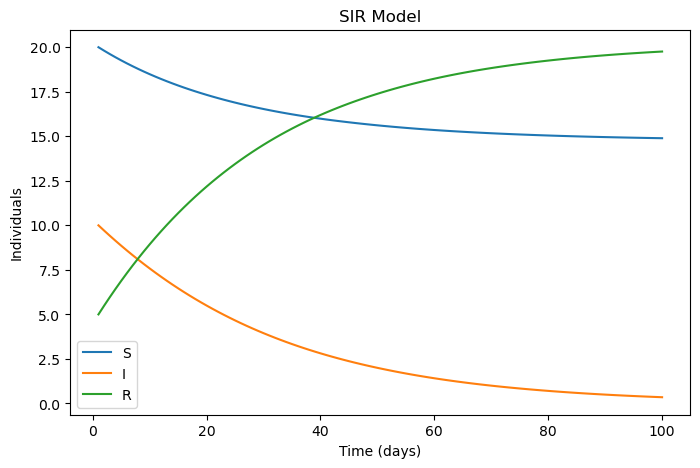

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# -----------------------
# SIR model
# -----------------------

def sir_model(t, y, beta, gamma):
    S, I, R = y

    dS = -beta * S * I
    dI = beta * S * I - gamma * I
    dR = gamma * I

    return [dS, dI, dR]

# Parameters
beta = 0.001
gamma = 0.05

# Initial conditions
y0 = [20, 10, 5]

# Time
t_span = (1, 100)
t_eval = np.arange(1, 101)

solution = solve_ivp(
    sir_model,
    t_span,
    y0,
    args=(beta, gamma),
    t_eval=t_eval
)

S, I, R = solution.y

plt.figure(figsize=(8,5))
plt.plot(solution.t, S, label="S")
plt.plot(solution.t, I, label="I")
plt.plot(solution.t, R, label="R")

plt.xlabel("Time (days)")
plt.ylabel("Individuals")
plt.title("SIR Model")
plt.legend()
plt.show()

In [7]:
#Exercise 1

#Now, just change beta = 0.01 or gamma = 0.0025 or y0 = [10,10,0] and rerun the solver.

In [8]:
#Part 2: Fit the SIR model to data

In [9]:
import numpy as np

day = np.arange(1,15)

flu = np.array([
    3,8,28,76,222,293,257,
    237,192,126,70,28,12,5
])

In [10]:
#Sum of squared errors

In [11]:
from scipy.optimize import minimize

def sse(params):

    beta, gamma = params

    solution = solve_ivp(
        sir_model,
        (1,14),
        [762,1,0],
        args=(beta,gamma),
        t_eval=day
    )

    predicted = solution.y[1]

    return np.sum((predicted - flu)**2)

In [12]:
#Optimize

In [13]:
guess = [0.01, 0.0025]

fit = minimize(
    sse,
    guess,
    method="Nelder-Mead"
)

print(fit.x)

[0.00256564 0.47374921]


In [14]:
#Plot fit

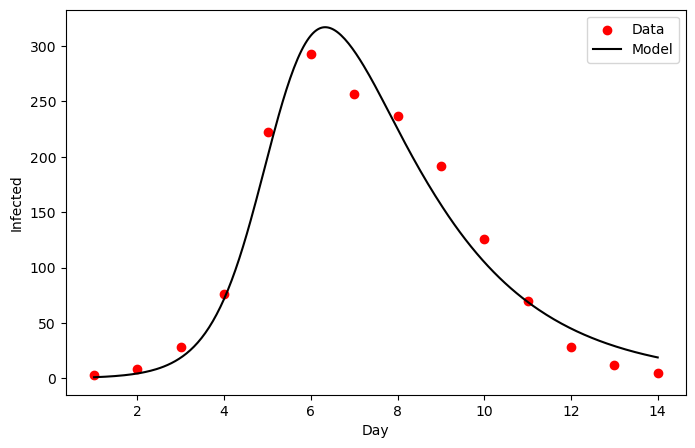

In [15]:
best_beta, best_gamma = fit.x

t = np.linspace(1,14,300)

solution = solve_ivp(
    sir_model,
    (1,14),
    [762,1,0],
    args=(best_beta,best_gamma),
    t_eval=t
)

plt.figure(figsize=(8,5))

plt.scatter(day, flu, color="red", label="Data")
plt.plot(t, solution.y[1], color="black", label="Model")

plt.xlabel("Day")
plt.ylabel("Infected")
plt.legend()
plt.show()

In [ ]:
#Exercise 2: Logistic Growth

#The continuous logistic equation

#dt/dN =rN(1− K/N)

#becomes

In [16]:
def logistic(t, N, r, K):
    return r * N * (1 - N/K)

In [17]:
#Simulation:

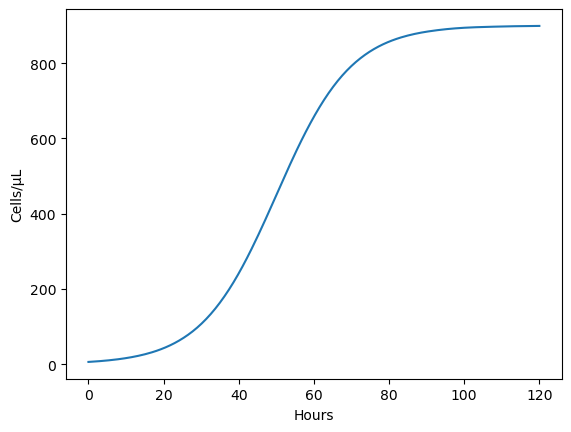

In [18]:
r = 0.1
K = 900

solution = solve_ivp(
    logistic,
    (0,120),
    [6],
    args=(r,K),
    t_eval=np.linspace(0,120,200)
)

plt.plot(solution.t, solution.y[0])
plt.xlabel("Hours")
plt.ylabel("Cells/µL")
plt.show()

In [ ]:
#Fit to the Cunningham & Maas data

In [ ]:
import pandas as pd

data = pd.read_csv("CunninghamMaasAlgaeData.csv")

In [ ]:
times = data["time"].values
cells = data["cells"].values

In [ ]:
#Define the SSE:

In [ ]:
def logistic_sse(params):

    r, K = params

    solution = solve_ivp(
        logistic,
        (times.min(), times.max()),
        [6],
        args=(r,K),
        t_eval=times
    )

    prediction = solution.y[0]

    return np.sum((prediction - cells)**2)

In [ ]:
#Optimize:

In [ ]:
fit = minimize(
    logistic_sse,
    [0.1,900],
    method="Nelder-Mead"
)

print(fit.x)

In [ ]:
#Plot:

In [ ]:
best_r, best_K = fit.x

t = np.linspace(0,120,300)

solution = solve_ivp(
    logistic,
    (0,120),
    [6],
    args=(best_r,best_K),
    t_eval=t
)

plt.scatter(times, cells, color="red", label="Data")
plt.plot(t, solution.y[0], color="black", label="Model")
plt.xlabel("Time (hours)")
plt.ylabel("Cells/µL")
plt.legend()
plt.show()